<a href="https://colab.research.google.com/github/smerarawal/Smart-Hospital-Appointment-System-with-No-Show-Predictor-and-Reschedule-Generation/blob/main/dbms1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mysql-connector-python sqlalchemy pymysql -q
print("Libraries installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.8 MB/s eta 0:00:00
Libraries installed.


In [ ]:
!pip install mysql-connector-python sqlalchemy pymysql -q

import mysql.connector, pandas as pd, numpy as np, matplotlib.pyplot as plt
from sqlalchemy import create_engine
import warnings; warnings.filterwarnings('ignore')

DB_HOST     = "centerbeam.proxy.rlwy.net"
DB_USER     = "root"
DB_PASSWORD = "uqqTtnLRCTBzVhUNDorIPByIknjemOAG"
DB_NAME     = "hospital_db"
DB_PORT     = 46001

engine = create_engine(f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print("Connected!")

# ── Generate data ──────────────────────────────────────────────────────────────
np.random.seed(42); N = 5000
departments  = ['Cardiology','General','Orthopaedics','Dermatology','Psychiatry','Oncology']
days_of_week = ['Monday','Tuesday','Wednesday','Thursday','Friday']

df = pd.DataFrame({
    'patient_id':         np.random.randint(1000,9999,N),
    'age':                np.random.randint(18,85,N),
    'department':         np.random.choice(departments,N),
    'day_of_week':        np.random.choice(days_of_week,N),
    'hour_of_day':        np.random.choice([8,9,10,11,13,14,15,16],N),
    'lead_time_days':     np.random.randint(0,90,N),
    'past_noshow_count':  np.random.randint(0,10,N),
    'past_cancellations': np.random.randint(0,6,N),
})

def noshow_prob(row):
    p = 0.15
    p += row['past_noshow_count']*0.05 + row['past_cancellations']*0.03
    p += (row['lead_time_days']/90)*0.20
    p += max(0,(40-row['age'])/40)*0.08
    p += {'Psychiatry':0.12,'Dermatology':0.08,'General':0.05,'Orthopaedics':0.02,'Cardiology':0.0,'Oncology':-0.05}.get(row['department'],0)
    p += {'Friday':0.10,'Monday':0.06,'Thursday':0.02,'Wednesday':0.0,'Tuesday':-0.02}.get(row['day_of_week'],0)
    if row['hour_of_day'] >= 15: p += 0.06
    return np.clip(p,0.05,0.95)

df['noshow_prob_true'] = df.apply(noshow_prob, axis=1)
df['no_show'] = (np.random.rand(N) < df['noshow_prob_true']).astype(int)
df.drop(columns=['noshow_prob_true'], inplace=True)
df.to_sql('appointments', engine, if_exists='replace', index=False)
print(f"Pushed {N} rows to MySQL. No-show rate: {df['no_show'].mean()*100:.1f}%")

# ── SQL Analysis ───────────────────────────────────────────────────────────────
print("\nNo-show rate by department:")
print(pd.read_sql("SELECT department, COUNT(*) AS total, ROUND(AVG(no_show)*100,1) AS noshow_pct FROM appointments GROUP BY department ORDER BY noshow_pct DESC", engine).to_string(index=False))

print("\nNo-show rate by day:")
print(pd.read_sql("SELECT day_of_week, ROUND(AVG(no_show)*100,1) AS noshow_pct FROM appointments GROUP BY day_of_week ORDER BY noshow_pct DESC", engine).to_string(index=False))

print("\nHigh-risk patients (5+ no-shows):")
print(pd.read_sql("SELECT patient_id, past_noshow_count, department FROM appointments WHERE past_noshow_count>=5 GROUP BY patient_id,past_noshow_count,department ORDER BY past_noshow_count DESC LIMIT 8", engine).to_string(index=False))

# ── Feature engineering → ml_features table ───────────────────────────────────
q = """
SELECT
    (@row_num := @row_num + 1)  AS appointment_id,
    age, lead_time_days, past_noshow_count, past_cancellations, hour_of_day,
    CASE WHEN department='Cardiology'   THEN 1 ELSE 0 END AS dept_cardiology,
    CASE WHEN department='Dermatology'  THEN 1 ELSE 0 END AS dept_dermatology,
    CASE WHEN department='General'      THEN 1 ELSE 0 END AS dept_general,
    CASE WHEN department='Oncology'     THEN 1 ELSE 0 END AS dept_oncology,
    CASE WHEN department='Orthopaedics' THEN 1 ELSE 0 END AS dept_ortho,
    CASE WHEN department='Psychiatry'   THEN 1 ELSE 0 END AS dept_psychiatry,
    CASE WHEN day_of_week='Monday'      THEN 1 ELSE 0 END AS day_monday,
    CASE WHEN day_of_week='Tuesday'     THEN 1 ELSE 0 END AS day_tuesday,
    CASE WHEN day_of_week='Wednesday'   THEN 1 ELSE 0 END AS day_wednesday,
    CASE WHEN day_of_week='Thursday'    THEN 1 ELSE 0 END AS day_thursday,
    CASE WHEN day_of_week='Friday'      THEN 1 ELSE 0 END AS day_friday,
    no_show
FROM appointments, (SELECT @row_num := 0) AS r
"""

ml_df = pd.read_sql(q, engine)
ml_df.to_sql('ml_features', engine, if_exists='replace', index=False)
ml_df.to_csv('ml_features.csv', index=False)
print(f"\nml_features table created: {ml_df.shape}")

# ── EDA Charts ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1,2,figsize=(13,4))
dept = pd.read_sql("SELECT department, ROUND(AVG(no_show)*100,1) AS rate FROM appointments GROUP BY department ORDER BY rate DESC", engine)
axes[0].barh(dept['department'], dept['rate'], color='#4f8ef7')
axes[0].set_xlabel('No-show rate (%)'); axes[0].set_title('By department')
day = pd.read_sql("SELECT day_of_week, ROUND(AVG(no_show)*100,1) AS rate FROM appointments GROUP BY day_of_week ORDER BY rate DESC", engine)
axes[1].bar(day['day_of_week'], day['rate'], color='#a78bfa')
axes[1].set_title('By day of week'); plt.xticks(rotation=20)
plt.tight_layout(); plt.savefig('eda_charts.png',dpi=150); plt.show()
print("Done! Run Notebook 2 next.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.2 MB/s eta 0:00:00
Connected!


ProgrammingError: (mysql.connector.errors.ProgrammingError) 1049 (42000): Unknown database 'hospital_db'
(Background on this error at: https://sqlalche.me/e/20/f405)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.7 MB/s eta 0:00:00
Connected!
Pushed 5015 rows to MySQL (5000 generated + 15 manual)
No-show rate: 65.3%

===== QUERY 1: No-show rate by department =====
  department  total  noshows  noshow_pct
  Psychiatry    841    626.0        74.4
 Dermatology    855    614.0        71.8
     General    866    590.0        68.1
  Cardiology    828    515.0        62.2
Orthopaedics    778    469.0        60.3
    Oncology    847    461.0        54.4

===== QUERY 2: No-show rate by day =====
day_of_week  total  noshow_pct
     Friday    963        71.0
     Monday   1027        69.7
   Thursday    980        63.0
  Wednesday    985        62.4
    Tuesday   1060        60.7

===== QUERY 3: No-show rate by hour =====
 hour_of_day  total  noshow_pct
           8    605        64.3
           9    607        65.2
          10    622        63.2
          11    671   

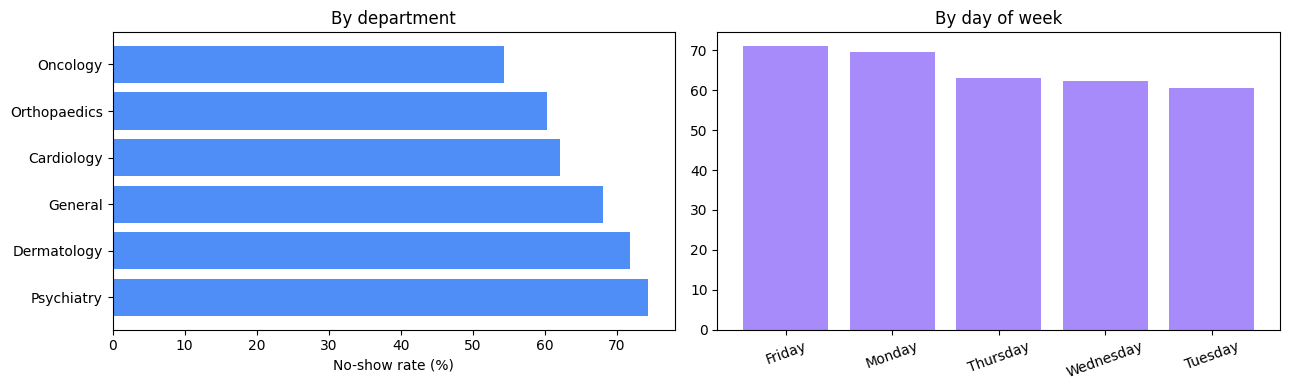

Notebook 1 done! Run Notebook 2 next.


In [ ]:
!pip install mysql-connector-python sqlalchemy pymysql -q

import pandas as pd, numpy as np, matplotlib.pyplot as plt
import mysql.connector
from sqlalchemy import create_engine
import warnings; warnings.filterwarnings('ignore')

DB_HOST="centerbeam.proxy.rlwy.net"; DB_USER="root"; DB_PASSWORD="uqqTtnLRCTBzVhUNDorIPByIknjemOAG"; DB_PORT=46001

# Create hospital_db on Railway
temp = mysql.connector.connect(host=DB_HOST, user=DB_USER, password=DB_PASSWORD, port=DB_PORT)
temp.cursor().execute("CREATE DATABASE IF NOT EXISTS hospital_db")
temp.close()

DB_NAME="hospital_db"
engine = create_engine(f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print("Connected!")

# Generate dataset
np.random.seed(42); N=5000
departments  = ['Cardiology','General','Orthopaedics','Dermatology','Psychiatry','Oncology']
days_of_week = ['Monday','Tuesday','Wednesday','Thursday','Friday']

df = pd.DataFrame({
    'patient_id':         np.random.randint(1000,9999,N),
    'age':                np.random.randint(18,85,N),
    'department':         np.random.choice(departments,N),
    'day_of_week':        np.random.choice(days_of_week,N),
    'hour_of_day':        np.random.choice([8,9,10,11,13,14,15,16],N),
    'lead_time_days':     np.random.randint(0,90,N),
    'past_noshow_count':  np.random.randint(0,10,N),
    'past_cancellations': np.random.randint(0,6,N),
})

def noshow_prob(row):
    p = 0.15
    p += row['past_noshow_count']*0.05 + row['past_cancellations']*0.03
    p += (row['lead_time_days']/90)*0.20
    p += max(0,(40-row['age'])/40)*0.08
    p += {'Psychiatry':0.12,'Dermatology':0.08,'General':0.05,'Orthopaedics':0.02,'Cardiology':0.0,'Oncology':-0.05}.get(row['department'],0)
    p += {'Friday':0.10,'Monday':0.06,'Thursday':0.02,'Wednesday':0.0,'Tuesday':-0.02}.get(row['day_of_week'],0)
    if row['hour_of_day'] >= 15: p += 0.06
    return np.clip(p,0.05,0.95)

df['noshow_prob_true'] = df.apply(noshow_prob, axis=1)
df['no_show'] = (np.random.rand(N) < df['noshow_prob_true']).astype(int)
df.drop(columns=['noshow_prob_true'], inplace=True)
df.insert(0, 'appointment_id', range(1, len(df)+1))

# Add 15 manual test patients
manual = pd.DataFrame([
    {'appointment_id':5001,'patient_id':101,'age':21,'department':'Psychiatry',  'day_of_week':'Friday',   'hour_of_day':16,'lead_time_days':70,'past_noshow_count':8,'past_cancellations':4,'no_show':1},
    {'appointment_id':5002,'patient_id':102,'age':19,'department':'Dermatology', 'day_of_week':'Friday',   'hour_of_day':15,'lead_time_days':65,'past_noshow_count':7,'past_cancellations':3,'no_show':1},
    {'appointment_id':5003,'patient_id':103,'age':25,'department':'Psychiatry',  'day_of_week':'Monday',   'hour_of_day':15,'lead_time_days':55,'past_noshow_count':6,'past_cancellations':3,'no_show':1},
    {'appointment_id':5004,'patient_id':104,'age':23,'department':'General',     'day_of_week':'Friday',   'hour_of_day':14,'lead_time_days':60,'past_noshow_count':7,'past_cancellations':2,'no_show':1},
    {'appointment_id':5005,'patient_id':105,'age':27,'department':'Dermatology', 'day_of_week':'Monday',   'hour_of_day':16,'lead_time_days':72,'past_noshow_count':9,'past_cancellations':4,'no_show':1},
    {'appointment_id':5006,'patient_id':106,'age':35,'department':'General',     'day_of_week':'Thursday', 'hour_of_day':13,'lead_time_days':30,'past_noshow_count':3,'past_cancellations':2,'no_show':1},
    {'appointment_id':5007,'patient_id':107,'age':40,'department':'Cardiology',  'day_of_week':'Monday',   'hour_of_day':14,'lead_time_days':25,'past_noshow_count':2,'past_cancellations':1,'no_show':0},
    {'appointment_id':5008,'patient_id':108,'age':38,'department':'Orthopaedics','day_of_week':'Wednesday','hour_of_day':11,'lead_time_days':20,'past_noshow_count':3,'past_cancellations':1,'no_show':1},
    {'appointment_id':5009,'patient_id':109,'age':42,'department':'General',     'day_of_week':'Thursday', 'hour_of_day':10,'lead_time_days':28,'past_noshow_count':2,'past_cancellations':2,'no_show':0},
    {'appointment_id':5010,'patient_id':110,'age':33,'department':'Dermatology', 'day_of_week':'Tuesday',  'hour_of_day':13,'lead_time_days':35,'past_noshow_count':4,'past_cancellations':1,'no_show':1},
    {'appointment_id':5011,'patient_id':111,'age':68,'department':'Oncology',    'day_of_week':'Tuesday',  'hour_of_day': 9,'lead_time_days': 3,'past_noshow_count':0,'past_cancellations':0,'no_show':0},
    {'appointment_id':5012,'patient_id':112,'age':72,'department':'Cardiology',  'day_of_week':'Wednesday','hour_of_day':10,'lead_time_days': 5,'past_noshow_count':0,'past_cancellations':0,'no_show':0},
    {'appointment_id':5013,'patient_id':113,'age':65,'department':'Oncology',    'day_of_week':'Tuesday',  'hour_of_day': 8,'lead_time_days': 2,'past_noshow_count':0,'past_cancellations':1,'no_show':0},
    {'appointment_id':5014,'patient_id':114,'age':58,'department':'Orthopaedics','day_of_week':'Wednesday','hour_of_day': 9,'lead_time_days': 7,'past_noshow_count':1,'past_cancellations':0,'no_show':0},
    {'appointment_id':5015,'patient_id':115,'age':61,'department':'Cardiology',  'day_of_week':'Tuesday',  'hour_of_day':10,'lead_time_days': 4,'past_noshow_count':0,'past_cancellations':0,'no_show':0},
])

df = pd.concat([df, manual], ignore_index=True)
df.to_sql('appointments', engine, if_exists='replace', index=False)
print(f"Pushed {len(df)} rows to MySQL (5000 generated + 15 manual)")
print(f"No-show rate: {df['no_show'].mean()*100:.1f}%")

# SQL Analysis queries
print("\n===== QUERY 1: No-show rate by department =====")
print(pd.read_sql("""
    SELECT department, COUNT(*) AS total,
           SUM(no_show) AS noshows,
           ROUND(AVG(no_show)*100,1) AS noshow_pct
    FROM appointments
    GROUP BY department ORDER BY noshow_pct DESC
""", engine).to_string(index=False))

print("\n===== QUERY 2: No-show rate by day =====")
print(pd.read_sql("""
    SELECT day_of_week, COUNT(*) AS total,
           ROUND(AVG(no_show)*100,1) AS noshow_pct
    FROM appointments
    GROUP BY day_of_week ORDER BY noshow_pct DESC
""", engine).to_string(index=False))

print("\n===== QUERY 3: No-show rate by hour =====")
print(pd.read_sql("""
    SELECT hour_of_day, COUNT(*) AS total,
           ROUND(AVG(no_show)*100,1) AS noshow_pct
    FROM appointments
    GROUP BY hour_of_day ORDER BY hour_of_day
""", engine).to_string(index=False))

print("\n===== QUERY 4: High risk patients (5+ no-shows) =====")
print(pd.read_sql("""
    SELECT patient_id, age, department, day_of_week,
           past_noshow_count, lead_time_days, no_show
    FROM appointments
    WHERE past_noshow_count >= 5
    ORDER BY past_noshow_count DESC LIMIT 10
""", engine).to_string(index=False))

print("\n===== QUERY 5: Our 15 manual test patients =====")
print(pd.read_sql("""
    SELECT patient_id, age, department, day_of_week,
           past_noshow_count, lead_time_days, no_show
    FROM appointments
    WHERE patient_id BETWEEN 101 AND 115
    ORDER BY patient_id
""", engine).to_string(index=False))

# Feature engineering
ml_df = pd.read_sql("""
    SELECT appointment_id, age, lead_time_days, past_noshow_count,
           past_cancellations, hour_of_day,
           CASE WHEN department='Cardiology'   THEN 1 ELSE 0 END AS dept_cardiology,
           CASE WHEN department='Dermatology'  THEN 1 ELSE 0 END AS dept_dermatology,
           CASE WHEN department='General'      THEN 1 ELSE 0 END AS dept_general,
           CASE WHEN department='Oncology'     THEN 1 ELSE 0 END AS dept_oncology,
           CASE WHEN department='Orthopaedics' THEN 1 ELSE 0 END AS dept_ortho,
           CASE WHEN department='Psychiatry'   THEN 1 ELSE 0 END AS dept_psychiatry,
           CASE WHEN day_of_week='Monday'      THEN 1 ELSE 0 END AS day_monday,
           CASE WHEN day_of_week='Tuesday'     THEN 1 ELSE 0 END AS day_tuesday,
           CASE WHEN day_of_week='Wednesday'   THEN 1 ELSE 0 END AS day_wednesday,
           CASE WHEN day_of_week='Thursday'    THEN 1 ELSE 0 END AS day_thursday,
           CASE WHEN day_of_week='Friday'      THEN 1 ELSE 0 END AS day_friday,
           no_show
    FROM appointments
""", engine)
ml_df.to_sql('ml_features', engine, if_exists='replace', index=False)
ml_df.to_csv('ml_features.csv', index=False)
print(f"\nml_features table created: {ml_df.shape}")

# EDA charts
fig, axes = plt.subplots(1,2,figsize=(13,4))
dept = pd.read_sql("SELECT department, ROUND(AVG(no_show)*100,1) AS rate FROM appointments GROUP BY department ORDER BY rate DESC", engine)
axes[0].barh(dept['department'], dept['rate'], color='#4f8ef7')
axes[0].set_xlabel('No-show rate (%)'); axes[0].set_title('By department')
day = pd.read_sql("SELECT day_of_week, ROUND(AVG(no_show)*100,1) AS rate FROM appointments GROUP BY day_of_week ORDER BY rate DESC", engine)
axes[1].bar(day['day_of_week'], day['rate'], color='#a78bfa')
axes[1].set_title('By day of week'); plt.xticks(rotation=20)
plt.tight_layout(); plt.savefig('eda_charts.png',dpi=150); plt.show()
print("Notebook 1 done! Run Notebook 2 next.")

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)
departments = ['Cardiology', 'Dermatology', 'General', 'Oncology', 'Orthopaedics', 'Psychiatry']
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
num_records = 5000

# 1. Generate realistic patient histories
df = pd.DataFrame({
    'patient_id': range(1, num_records + 1),
    'age': np.random.randint(18, 85, num_records),
    'department': np.random.choice(departments, num_records),
    'day_of_week': np.random.choice(days, num_records),
    'hour_of_day': np.random.choice([8, 9, 10, 11, 13, 14, 15, 16], num_records),
    'lead_time_days': np.random.randint(1, 90, num_records),
    'past_noshow_count': np.random.choice([0, 0, 0, 1, 2, 3, 4], num_records), # Skewed so most people have 0
    'past_cancellations': np.random.choice([0, 0, 1, 2], num_records)
})

# 2. The Logic Engine: Calculate true risk based on features
def calculate_true_risk(row):
    prob = 0.10 # Base 10% risk for everyone

    if row['past_noshow_count'] > 0: prob += (0.30 * row['past_noshow_count'])
    if row['past_cancellations'] > 0: prob += (0.10 * row['past_cancellations'])
    if row['lead_time_days'] > 30: prob += 0.20
    if row['lead_time_days'] <= 3: prob -= 0.15

    return max(0.02, min(0.98, prob)) # Keep between 2% and 98%

# Apply the logic
df['true_risk_score'] = df.apply(calculate_true_risk, axis=1)

# 3. Finalize the outcome (1 or 0) based on their logical risk
df['no_show'] = [np.random.binomial(1, p) for p in df['true_risk_score']]

# 4. Hide the answer key! We drop the true score so the ML has to learn it itself.
df = df.drop(columns=['true_risk_score'])

# Save for Notebook 2
df.to_csv('logical_patients.csv', index=False)
print("✅ Generated 5,000 logically sound patients and saved to logical_patients.csv!")

✅ Generated 5,000 logically sound patients and saved to logical_patients.csv!


In [ ]:
from google.colab import files
files.download('logical_patients.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>